In [146]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [148]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

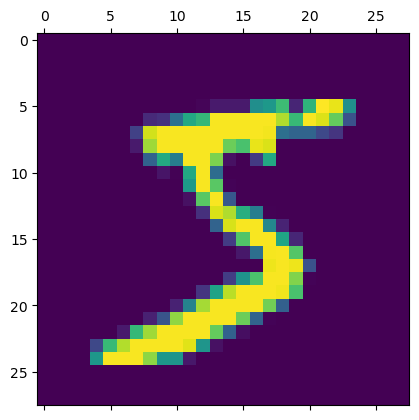

In [150]:
plt.matshow(X_train[0])

In [152]:
X_train=X_train/255
X_test=X_test/255

In [154]:
flat_1=X_train.reshape(len(X_train),28*28)
flat_2=X_test.reshape(len(X_test),28*28)

In [156]:
#Simple Model


model=keras.Sequential([keras.layers.Dense(10,input_shape=(784,),activation='sigmoid')])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(flat_1,y_train,epochs=5)

C:\Users\pradhumn.c\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 854us/step - accuracy: 0.8124 - loss: 0.7223
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - accuracy: 0.9120 - loss: 0.3129
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 810us/step - accuracy: 0.9229 - loss: 0.2830
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 825us/step - accuracy: 0.9244 - loss: 0.2720
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 847us/step - accuracy: 0.9267 - loss: 0.2642


In [158]:
prediction=model.predict(flat_2)
evaluate=model.evaluate(flat_2,y_test)
print("Model Prediction\n",prediction)
print("")
print("Model Evaluation",evaluate)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - accuracy: 0.9153 - loss: 0.3027
Model Prediction
 [[2.8004263e-02 3.6761972e-07 4.8783433e-02 ... 9.9972165e-01
  8.4525377e-02 5.5834961e-01]
 [4.7196066e-01 1.1324598e-02 9.9942720e-01 ... 5.2867622e-13
  2.6050276e-01 2.8213878e-09]
 [4.9701682e-04 9.9445790e-01 6.7390954e-01 ... 1.1224659e-01
  4.0789300e-01 4.3418713e-02]
 ...
 [3.8323606e-06 6.9386992e-06 8.8348635e-04 ... 1.5907797e-01
  5.4053354e-01 5.9860754e-01]
 [1.9119491e-04 2.2545847e-04 1.3116693e-04 ... 4.1687959e-05
  7.3161161e-01 7.6719065e-05]
 [1.0124461e-02 7.1191097e-10 1.7611308e-01 ... 6.8316433e-09
  3.2391111e-04 4.9244301e-07]]

Model Evaluation [0.2685249447822571, 0.9262999892234802]


The Predicted value is:  0
The actual value is:


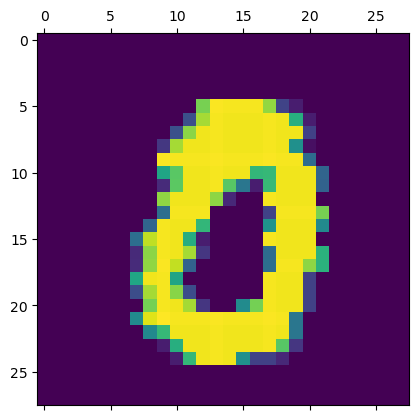

In [160]:
plt.matshow(X_train[69])
print("The Predicted value is: ",np.argmax(prediction[69]))
print("The actual value is:")

In [162]:
y_predict=[np.argmax(i) for i in prediction]
matrix=tf.math.confusion_matrix(labels=y_test,predictions=y_predict)

Text(95.72222222222221, 0.5, 'Actual')

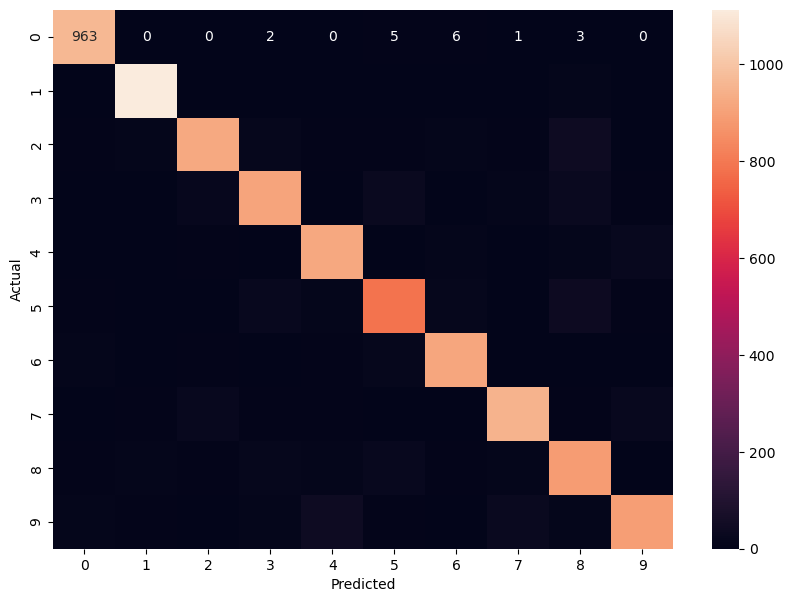

In [168]:
import seaborn as sn
plt.figure(figsize= (10,7))
sn.heatmap(matrix,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [192]:
#Hidden Layer for improving Accuracy

model_1=keras.Sequential([
    keras.layers.Dense(420,input_shape=(784,),activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])
model_1.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model_1.fit(flat_1,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8985 - loss: 0.3479
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9740 - loss: 0.0857
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9844 - loss: 0.0520
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9887 - loss: 0.0359
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9920 - loss: 0.0253


In [194]:
prediction_1=model_1.predict(flat_2)
evaluate_1=model_1.evaluate(flat_2,y_test)
print("Model Prediction\n",prediction_1)
print("")
print("Model Evaluation",evaluate_1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9759 - loss: 0.0845
Model Prediction
 [[8.79925967e-04 1.05189590e-03 6.96797222e-02 ... 9.99998212e-01
  1.02469919e-03 4.38561082e-01]
 [4.74612432e-04 9.27101552e-01 1.00000000e+00 ... 4.47873170e-08
  2.22811103e-03 1.69769152e-07]
 [4.87163743e-06 9.99082863e-01 4.92030382e-03 ... 6.83052540e-02
  3.53899777e-01 4.79715003e-04]
 ...
 [3.58402815e-07 1.07819615e-04 5.76371394e-06 ... 2.46534809e-01
  7.33197555e-02 9.48686004e-01]
 [3.21885920e-03 2.12969862e-05 4.42491637e-06 ... 2.26775956e-04
  9.91887331e-01 3.89338993e-06]
 [1.50443390e-02 1.19993703e-04 1.25973135e-01 ... 2.01285175e-07
  8.69372670e-05 2.18038636e-04]]

Model Evaluation [0.07259693741798401, 0.9793999791145325]


In [196]:
y_prediction=[np.argmax(i) for i in prediction_1]
matrix_1=tf.math.confusion_matrix(labels=y_test,predictions=y_prediction)

Text(95.72222222222221, 0.5, 'Actual')

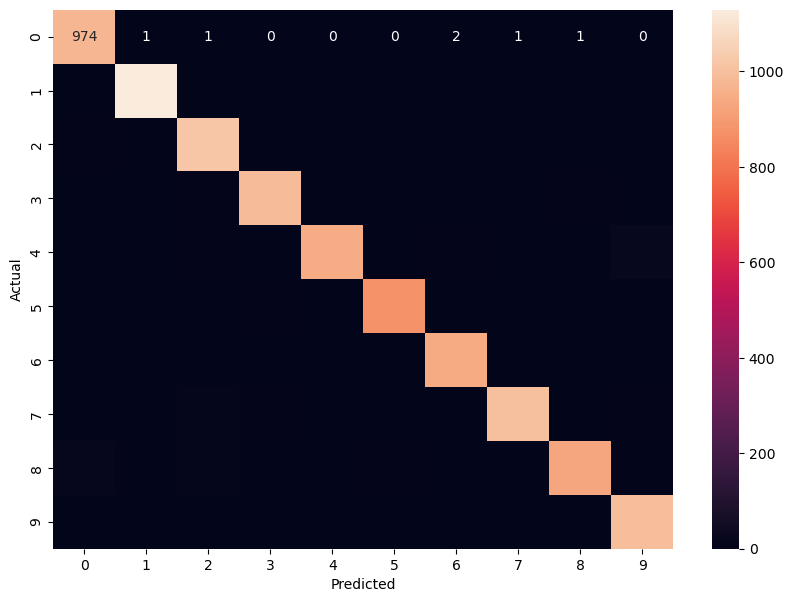

In [208]:
import seaborn as sn
plt.figure(figsize= (10,7))
sn.heatmap(matrix_1,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")